# YOLOv8 Video Inference — RTX3060_PC

Runs all three trained models on the **same video file** under identical inference settings.
Metrics: total detections, per-class counts, mean/median/std confidence, confidence distribution, inference FPS.

**Device:** Desktop PC — NVIDIA RTX 3060 12 GB, CUDA

## 1 — Install dependencies

In [1]:
!pip install ultralytics --quiet
import ultralytics
print(f'Ultralytics: {ultralytics.__version__}')

Ultralytics: 8.4.50


## 2 — Environment info (log in thesis)

In [2]:
import torch, platform

print('=== Inference Environment ===')
print('Device        : RTX3060_PC')
print(f'OS            : {platform.platform()}')
print(f'Python        : {platform.python_version()}')
print(f'PyTorch       : {torch.__version__}')

if torch.cuda.is_available():
    DEVICE = 0
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    print('Accelerator   : Apple MPS (Metal)')
else:
    DEVICE = 'cpu'
    print('Accelerator   : CPU only')

print(f'Inference device selected: {DEVICE}')

=== Inference Environment ===
Device        : RTX3060_PC
OS            : Windows-10-10.0.19045-SP0
Python        : 3.11.15
PyTorch       : 2.5.1+cu121
GPU           : NVIDIA GeForce RTX 3060
VRAM          : 12.88 GB
Inference device selected: 0


## 3 — Configuration

In [3]:
import os

# ── Trained weights — copy runs/ from the training PC if needed ──────
MODELS = [
    {'name': 'yolov8n', 'weights': 'runs/detect/yolov8n_thesis/weights/best.pt'},
    {'name': 'yolov8s', 'weights': 'runs/detect/yolov8s_thesis/weights/best.pt'},
    {'name': 'yolov8m', 'weights': 'runs/detect/yolov8m_thesis/weights/best.pt'},
]

# ── Same video on every device ────────────────────────────────────────
VIDEO_PATH = 'inference_test.mp4'  # <-- update this path

# ── Inference settings — IDENTICAL across all models & devices ────────
IMGSZ   = 640
CONF    = 0.25   # confidence threshold
IOU     = 0.45
MAX_DET = 300

for m in MODELS:
    print(f"{m['name']:10s} weights found: {os.path.isfile(m['weights'])}")
assert os.path.isfile(VIDEO_PATH), f'Video not found: {VIDEO_PATH}'
print(f'Video OK: {VIDEO_PATH}')

yolov8n    weights found: True
yolov8s    weights found: True
yolov8m    weights found: True
Video OK: inference_test.mp4


## 4 — Run inference

Uses `stream=True` so frames are processed one-by-one without loading the whole video into RAM. No output video is written.

In [4]:
from ultralytics import YOLO
import time, gc, collections
import numpy as np

_tmp = YOLO(MODELS[0]['weights'])
CLASS_NAMES = _tmp.names
del _tmp
print(f'Classes: {CLASS_NAMES}\n')

raw_results = {}

for cfg in MODELS:
    print(f"{'='*55}")
    print(f"  Running : {cfg['name']}")
    print(f"{'='*55}")

    gc.collect()
    if str(DEVICE) == '0':
        torch.cuda.empty_cache()

    model = YOLO(cfg['weights'])
    frame_data = []
    t0 = time.perf_counter()

    preds = model.predict(
        source  = VIDEO_PATH,
        imgsz   = IMGSZ,
        conf    = CONF,
        iou     = IOU,
        max_det = MAX_DET,
        device  = DEVICE,
        stream  = True,
        save    = False,
        verbose = False,
    )

    for frame_idx, r in enumerate(preds):
        boxes = r.boxes
        if boxes is not None and len(boxes) > 0:
            confs   = boxes.conf.cpu().numpy().tolist()
            cls_ids = boxes.cls.cpu().numpy().astype(int).tolist()
        else:
            confs, cls_ids = [], []
        frame_data.append({'frame': frame_idx, 'n_dets': len(confs),
                            'confs': confs, 'cls_ids': cls_ids})

    elapsed = time.perf_counter() - t0
    raw_results[cfg['name']] = {'frames': frame_data, 'total_time_s': elapsed}
    print(f"  {len(frame_data)} frames in {elapsed:.1f}s  ({len(frame_data)/elapsed:.1f} FPS)\n")

print('Inference complete.')

Classes: {0: 'ball', 1: 'player'}

  Running : yolov8n
  750 frames in 9.6s  (78.3 FPS)

  Running : yolov8s
  750 frames in 9.1s  (82.3 FPS)

  Running : yolov8m
  750 frames in 13.6s  (55.1 FPS)

Inference complete.


## 5 — Compute metrics

In [5]:
import pandas as pd

CONF_BINS       = [0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.01]
CONF_BIN_LABELS = ['0.25-0.30','0.30-0.40','0.40-0.50','0.50-0.60',
                   '0.60-0.70','0.70-0.80','0.80-0.90','0.90-1.00']

summary_rows   = []
conf_dist_rows = []

for cfg in MODELS:
    name     = cfg['name']
    data     = raw_results[name]
    frames   = data['frames']
    t        = data['total_time_s']
    n_frames = len(frames)

    all_confs   = [c for f in frames for c in f['confs']]
    all_cls_ids = [c for f in frames for c in f['cls_ids']]
    total_dets  = len(all_confs)

    cls_counts = collections.Counter(all_cls_ids)
    per_class  = {CLASS_NAMES[i]: cls_counts.get(i, 0) for i in CLASS_NAMES}

    mean_conf        = float(np.mean(all_confs))   if all_confs else 0.0
    median_conf      = float(np.median(all_confs)) if all_confs else 0.0
    std_conf         = float(np.std(all_confs))    if all_confs else 0.0
    zero_det_frames  = sum(1 for f in frames if f['n_dets'] == 0)

    row = {
        'Model'             : name,
        'Frames processed'  : n_frames,
        'Total detections'  : total_dets,
        'Dets/frame (mean)' : round(total_dets / n_frames, 2) if n_frames else 0,
        'Frames w/ 0 dets'  : zero_det_frames,
        'Mean confidence'   : round(mean_conf,   4),
        'Median confidence' : round(median_conf, 4),
        'Std confidence'    : round(std_conf,    4),
        'Total time (s)'    : round(t, 2),
        'Inference FPS'     : round(n_frames / t, 1),
    }
    row.update({f'Dets [{c}]': per_class[c] for c in per_class})
    summary_rows.append(row)

    counts, _ = np.histogram(all_confs, bins=CONF_BINS)
    for lbl, cnt in zip(CONF_BIN_LABELS, counts):
        conf_dist_rows.append({'Model': name, 'Conf bin': lbl, 'Count': int(cnt)})

df_summary   = pd.DataFrame(summary_rows)
df_conf_dist = pd.DataFrame(conf_dist_rows)

print('=== Inference Summary ===')
print(df_summary[['Model','Total detections','Dets/frame (mean)',
                  'Mean confidence','Median confidence','Std confidence',
                  'Frames w/ 0 dets','Inference FPS']].to_string(index=False))

print('\n=== Per-class Detection Counts ===')
cls_cols = ['Model'] + [f'Dets [{c}]' for c in CLASS_NAMES.values()]
print(df_summary[cls_cols].to_string(index=False))

print('\n=== Confidence Distribution ===')
pivot = df_conf_dist.pivot(index='Conf bin', columns='Model', values='Count').fillna(0).astype(int)
print(pivot.to_string())

=== Inference Summary ===
  Model  Total detections  Dets/frame (mean)  Mean confidence  Median confidence  Std confidence  Frames w/ 0 dets  Inference FPS
yolov8n             15518              20.69           0.5030             0.5201          0.1088                 0           78.3
yolov8s             17114              22.82           0.5633             0.5907          0.1191                 0           82.3
yolov8m             16686              22.25           0.5777             0.6087          0.1112                 0           55.1

=== Per-class Detection Counts ===
  Model  Dets [ball]  Dets [player]
yolov8n          319          15199
yolov8s          717          16397
yolov8m          529          16157

=== Confidence Distribution ===
Model      yolov8m  yolov8n  yolov8s
Conf bin                            
0.25-0.30      520      801      689
0.30-0.40     1125     2247     1462
0.40-0.50     1824     3680     2253
0.50-0.60     4299     5583     4691
0.60-0.70     7833 

## 6 — Save CSVs

In [6]:
PREFIX = 'inference_RTX3060_PC'

df_summary.to_csv(f'{PREFIX}_summary.csv', index=False)
df_conf_dist.to_csv(f'{PREFIX}_conf_distribution.csv', index=False)
pivot.to_csv(f'{PREFIX}_conf_pivot.csv')
print(f'Saved: {PREFIX}_summary.csv')
print(f'Saved: {PREFIX}_conf_distribution.csv')
print(f'Saved: {PREFIX}_conf_pivot.csv')

Saved: inference_RTX3060_PC_summary.csv
Saved: inference_RTX3060_PC_conf_distribution.csv
Saved: inference_RTX3060_PC_conf_pivot.csv


## 7 — Confidence distribution plot

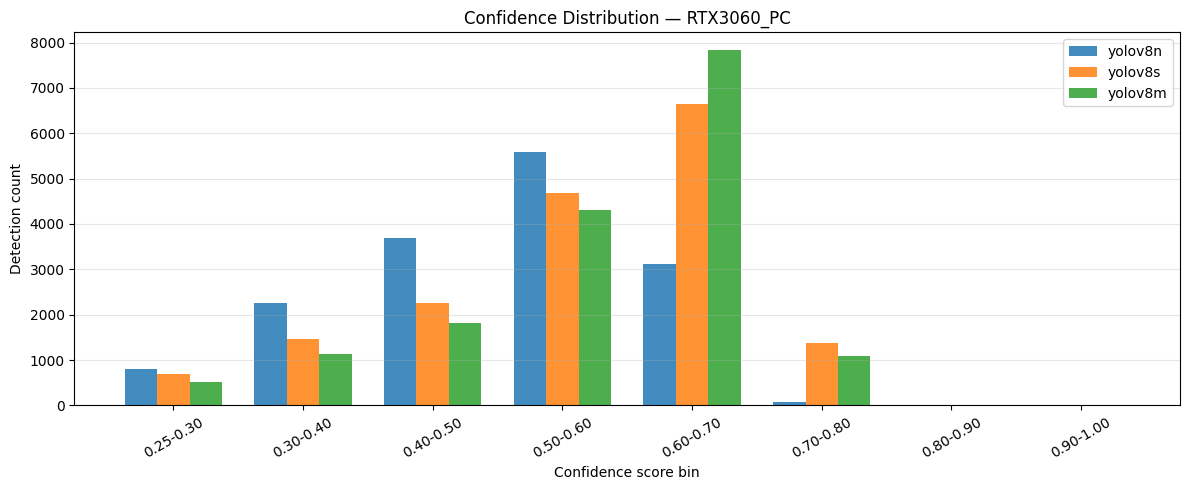

Plot saved.


In [7]:
import matplotlib.pyplot as plt

colors = {'yolov8n': 'tab:blue', 'yolov8s': 'tab:orange', 'yolov8m': 'tab:green'}
x     = np.arange(len(CONF_BIN_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, cfg in enumerate(MODELS):
    name = cfg['name']
    cnts = df_conf_dist[df_conf_dist['Model'] == name]['Count'].values
    ax.bar(x + (i - 1) * width, cnts, width,
           label=name, color=colors[name], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CONF_BIN_LABELS, rotation=30)
ax.set_xlabel('Confidence score bin')
ax.set_ylabel('Detection count')
ax.set_title('Confidence Distribution — RTX3060_PC')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PREFIX}_conf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')